## Importing the necessary libraries

In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time
from thefuzz import process, fuzz
import re
import unicodedata



# Data preparation

## 1-Data Inspection

#### Load data

In [137]:
df_hit=pd.read_csv('homeintunisia_maison_location.csv')

In [138]:
df_mub_location=pd.read_csv('mubawab_maison_location.csv')

In [139]:
df_mub_vacanes=pd.read_csv('mubawab_maison_vacance.csv')

In [140]:
df_remax=pd.read_csv('remax_maison_location.csv')

#### Inspect data

In [141]:
df_hit.head(3)

,link,title,address,price,type,Référence,Pièces,Surface,Surface totale,Type de chauffage,...,Terrasse 16 m²,Cour 15 m²,Faux plafond,Jeu de boules,Balcon 8 m²,Chambre 12 m²,Chambre 17 m²,Balcon 6 m²,Séjour,Balcons
0,https://www.homeintunisia.com/fr/propri%C3%A9t...,À louer – Villa non meublée à Kantaoui Narjess...,El Kantaoui,4 000 TND / Mois,Maison,85843732,6 pièces,800 m²,1000 m²,Radiateur,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.homeintunisia.com/fr/propri%C3%A9t...,Gîte rural de charme à 15 minutes du port El K...,Chatt Meriem,14 000 TND / Mois,Maison,85613498,NaN,800 m²,7791 m²,"Radiateur, Climatisation",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.homeintunisia.com/fr/propri%C3%A9t...,Villa de Luxe avec Piscine à Chott Meriem - Vo...,Tantana,6 000 TND / Mois,Maison,85558761,5 pièces,200 m²,1100 m²,Central,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### shape of the data (number of rows, number of columns)

In [142]:
df_hit.shape

(42, 142)

In [143]:
df_mub_location.shape

(2331, 51)

In [144]:
df_mub_vacanes.shape

(313, 46)

In [145]:
df_remax.shape

(49, 115)

In [146]:
euro_to_dinar=3.38

##### column names

In [147]:
df_hit.columns

Index(['link', 'title', 'address', 'price', 'type', 'Référence', 'Pièces',
       'Surface', 'Surface totale', 'Type de chauffage',
       ...
       'Terrasse 16 m²', 'Cour 15 m²', 'Faux plafond', 'Jeu de boules',
       'Balcon 8 m²', 'Chambre 12 m²', 'Chambre 17 m²', 'Balcon 6 m²',
       'Séjour', 'Balcons'],
      dtype='object', length=142)

In [148]:
df_remax.columns

Index(['link', 'title', 'prix', 'payment_method', 'latitude', 'longitude',
       'address', 'statut_marche', 'Nombre de pièces', 'Nombre de chambres',
       ...
       'Jacuzzi', '24/7 Securité', 'Sur route fréquentée',
       'Double Glass Window', 'Partiellement meublé', 'Près de la gare',
       'Piscine extérieure', 'Zone commerciale', 'Salle de jeux',
       'Piscine intérieure'],
      dtype='object', length=115)

In [149]:
df_mub_location.columns

Index(['link', 'title', 'address', 'price', 'm²', 'Pièces', 'Chambres',
       'Salles de bains', 'Jardin', 'Garage', 'Piscine', 'Chauffage central',
       'Cuisine équipée', 'Type de bien', 'Etat', 'Etat du bien',
       'Type du sol', 'latitude', 'longitude', 'Terrasse', 'Concierge',
       'Cheminée', 'Climatisation', 'Porte blindée', 'Réfrigérateur', 'Four',
       'Chambre rangement', 'Entre-seul', 'Salon européen',
       'Antenne parabolique', 'Sécurité', 'Double vitrage', 'Nombre d'étages',
       'Pièce', 'Internet', 'Micro-ondes', 'Animaux domestiques autorisés',
       'Surface de la parcelle', 'Meublé', 'TV', 'Machine à laver',
       'Salle de bain', 'Ascenseur', 'Vue sur mer', 'Vue sur les montagnes',
       'Orientation', 'Chambre', 'Surface habitable', 'Standing', 'État',
       'Livraison:'],
      dtype='object')

In [150]:
df_mub_vacanes.columns

Index(['link', 'title', 'address', 'price', 'm²', 'Pièces', 'Chambres',
       'Salle de bain', 'nuits min.', 'Jardin', 'Terrasse', 'Vue sur mer',
       'Piscine', 'Climatisation', 'Cuisine équipée', 'Réfrigérateur', 'Four',
       'TV', 'Machine à laver', 'Type de bien', 'Etat', 'latitude',
       'longitude', 'Chauffage central', 'Salles de bains', 'Garage',
       'Sécurité', 'Porte blindée', 'Micro-ondes', 'Internet',
       'Surface de la parcelle', 'Concierge', 'Façade extérieure', 'Cheminée',
       'Nombre d'étages', 'Salon européen', 'Antenne parabolique',
       'Double vitrage', 'Orientation', 'Vue sur les montagnes', 'Pièce',
       'Entre-seul', 'Animaux domestiques autorisés', 'Type du sol', 'Chambre',
       'Ascenseur'],
      dtype='object')

#### matching columns

In [151]:
cols_mub=['price','address', 'm²','Pièces','Salle de bain', 'Terrasse',
         'Meublé','Climatisation','Chauffage central', 'Sécurité',
         "Nombre d'étages",'latitude', 'longitude', 'Chambres', 'Garage', 'Jardin', 'Piscine',
        'Surface habitable', 'Salles de bains']
cols_renamed = {
    'm²': 'total_area',
    'Surface habitable':  'living_area',
    'Pièces': 'rooms',
    'Chambres': 'bedrooms',
    'Salles de bains': 'bathrooms',
    'Salle de bain': 'bathroom',
    'Jardin': 'garden',
    'Garage': 'garage',
    'Piscine': 'pool',
    'Chauffage central': 'heating',
    'latitude': 'latitude',
    'longitude': 'longitude',
    'Terrasse': 'terrace',
    'Climatisation': 'air_conditioning',
    'Surface de la parcelle': 'total_area',  #
    'Meublé': 'furnished',
    "Sécurité":"security",
    "Nombre d'étages":"floor_number"
}
# Assuming df is your DataFrame
df_mub_location = df_mub_location[cols_mub].rename(columns=cols_renamed)
df_mub_location["payment_period"]="Mois"
df_mub_location.columns

Index(['price', 'address', 'total_area', 'rooms', 'bathroom', 'terrace',
       'furnished', 'air_conditioning', 'heating', 'security', 'floor_number',
       'latitude', 'longitude', 'bedrooms', 'garage', 'garden', 'pool',
       'living_area', 'bathrooms', 'payment_period'],
      dtype='object')

In [152]:
df_mub_vacanes['Meublé']=1
df_mub_vacanes["Surface habitable"]=None
df_mub_vacanes= df_mub_vacanes[cols_mub].rename(columns=cols_renamed)
df_mub_vacanes.columns


Index(['price', 'address', 'total_area', 'rooms', 'bathroom', 'terrace',
       'furnished', 'air_conditioning', 'heating', 'security', 'floor_number',
       'latitude', 'longitude', 'bedrooms', 'garage', 'garden', 'pool',
       'living_area', 'bathrooms'],
      dtype='object')

In [153]:
hit_cols=df_hit.columns
hit_cols[90::]

Index(['Lave-vaisselle', 'Immeuble classé/inscrit', 'Télédistribution',
       'Groupe électrogène', 'Sèche-cheveux', 'Sèche-linge', 'Téléphone',
       'Terrain 1400 m²', 'Buanderie commune', 'Jardin 500 m²',
       'Panneaux photovoltaïques', 'Terrain 2500 m²', 'Concierge',
       'Moustiquaires', 'Salons', 'Garage', 'Lecteur DVD', 'Lecteur CD',
       'Ascenseur', 'Piscine en copropriété', 'Fibre optique', 'Digicode',
       'Coffre-fort', 'Terrasse', 'Suite', 'Terrasse 90 m²', 'Balcon',
       'Salle de sport', 'Cour', 'Local à vélo', 'Terrasse 300 m²',
       'Domotique', 'Ventilation double flux', 'Sauna', 'Spa',
       'Abri de jardin 72 m²', 'Studio 48 m²', 'Golf', 'Tennis',
       'Terrasse 60 m²', 'Parking', 'Appartement 122 m²', 'Terrasse 16 m²',
       'Cour 15 m²', 'Faux plafond', 'Jeu de boules', 'Balcon 8 m²',
       'Chambre 12 m²', 'Chambre 17 m²', 'Balcon 6 m²', 'Séjour', 'Balcons'],
      dtype='object')

In [154]:
cols_hit=['price','address','Pièces','Surface','Surface totale','Salles de bains','Salle de bains'
                    ,'Étage','Type de chauffage','Piscine','latitude','longitude',
                    'Air conditionné','Meublé','Piscine en copropriété',
                    'Terrasse','Alarme','Vidéo surveillance','Garage','Jardin']
df_hit=df_hit[cols_hit]
# Using pandas rename method directly
df_hit = df_hit.rename(columns={
    'Pièces': 'rooms',
    'Surface': 'living_area',
    'Surface totale': 'total_area',
    'Étage': 'floor',
    'Salon': 'living_room',
    'Chambres': 'bedrooms',
    'Piscine': 'pool',
    'Air conditionné': 'air_conditioning',
    'Meublé': 'furnished',
    'Piscine en copropriété': 'shared_pool',
    'Salles de bains':'bathrooms',
    'Salle de bains':'bathroom',
    'Type de chauffage':'heating',
    'Terrasse':'terrace',
    'Alarme':'alarm',
    'Vidéo surveillance':'video_surveillance',
    'Garage':'garage',
    'Jardin':'garden'
})
df_hit.columns

Index(['price', 'address', 'rooms', 'living_area', 'total_area', 'bathrooms',
       'bathroom', 'floor', 'heating', 'pool', 'latitude', 'longitude',
       'air_conditioning', 'furnished', 'shared_pool', 'terrace', 'alarm',
       'video_surveillance', 'garage', 'garden'],
      dtype='object')

In [155]:
cols_remax=["prix",'address',"payment_method",'latitude','longitude',"Nombre de pièces",
            "m²","Surface Terrain (m²)","Nombre d'étages","Meublé","Air Conditionné",
            'Chauffage au sol','Chauffage Central','Nombre salles de bain',
            "Système d'alarme",'Système de sécurité', 'Système de surveillance','Camera de sécurité',
            'Garage',"Terrasse","Jardin"]
df_remax=df_remax[cols_remax]
df_remax = df_remax.rename(columns={
    "prix":"price",
    "payment_method":"payment_period",
    'Nombre de pièces': 'rooms',
    'm²': 'living_area',
    'Surface Terrain (m²)': 'total_area',
    'État': 'condition',
    "Nombre d'étages": 'floor_number',
    'Salon': 'living_room',
    'Air Conditionné': 'air_conditioning',
    'Meublé': 'furnished',
    "Garage": "garage",
    "Jardin": "garden",
    "Terrasse": "terrace",
    "Nombre salles de bain":"bathrooms_number"
})
df_remax["pool"]=None
df_remax.columns

Index(['price', 'address', 'payment_period', 'latitude', 'longitude', 'rooms',
       'living_area', 'total_area', 'floor_number', 'furnished',
       'air_conditioning', 'Chauffage au sol', 'Chauffage Central',
       'bathrooms_number', 'Système d'alarme', 'Système de sécurité',
       'Système de surveillance', 'Camera de sécurité', 'garage', 'terrace',
       'garden', 'pool'],
      dtype='object')

## 2- Data Cleaning

### a-standardizing Formats

-df_hit

In [156]:
df_hit["price"].head(10)

0     4 000 TND / Mois
1    14 000 TND / Mois
2     6 000 TND / Mois
3     5 000 TND / Mois
4     2 000 TND / Mois
5     2 000 TND / Mois
6     2 500 TND / Mois
7     3 000 TND / Mois
8     3 500 TND / Mois
9      36 000 TND / An
Name: price, dtype: object

In [157]:
print(df_hit.shape)
df_hit=df_hit[df_hit['price']!="Prix sur demande"]
print(df_hit.shape)

(42, 20)
(39, 20)


In [158]:
df_hit['price'].sample(5)

33    À partir de 5 600 TND / Semaine
13                   1 600 TND / Mois
16         À partir de 288 TND / Jour
28         À partir de 700 TND / Jour
40         À partir de 880 TND / Jour
Name: price, dtype: object

In [159]:
# Function to extract both price value and payment period from price column
def extract_price_info(price_str):
    """
    -r'([0-9\s\u202f]+(?:[,.]\d+)?)\s*(?:TND)' : 
      It looks for digits, spaces, or special space characters
      Followed by optional decimal part
      Followed by "TND"
      exemple : À partir de 500 TND / Jour => group(1) gives us 500
    -re.search(r'/\s*(\w+)', price_str):
        The pattern finds the slash "/"
        Skips any spaces after the slash
        Captures "Jour/Semaine/Mois" in the group (\w+)
    """
    if not isinstance(price_str, str):
        return None, None   
    # Extract numeric part and payment period
    price_match = re.search(r'([0-9\s\u202f]+(?:[,.]\d+)?)\s*(?:TND)', price_str) #exract price fril string
    period_match = re.search(r'/\s*(\w+)', price_str)
    
    price_value = None
    if price_match:
        # Clean and normalize the price string
        price = price_match.group(1).strip()
        price = unicodedata.normalize('NFKD', price)
        price = re.sub(r'\s', '', price)
        price = price.replace(',', '.')
        
        try:
            price_value = float(price)
        except ValueError:
            print(f"Could not convert: {price} from original: {price_str}")
    
    # Extract period (Jour, Mois, Semaine, etc.)
    payment_period = period_match.group(1) if period_match else None
    
    return price_value, payment_period

df_hit['payment_period'] = None

for idx, row in df_hit.iterrows():
    price_value, period = extract_price_info(row['price'])
    if price_value is not None:
        df_hit.at[idx, 'price'] = price_value  # Update price column directly
    df_hit.at[idx, 'payment_period'] = period

In [160]:
df_hit[['price', 'payment_period']].sample(5)

,price,payment_period
5,2000.0,Mois
20,2070.0,Jour
22,1400.0,Jour
9,36000.0,An
29,500.0,Jour


In [161]:
df_hit['price']=df_hit['price'].astype(float)
print(df_hit[['price', 'payment_period']].head(10))

     price payment_period
0   4000.0           Mois
1  14000.0           Mois
2   6000.0           Mois
3   5000.0           Mois
4   2000.0           Mois
5   2000.0           Mois
6   2500.0           Mois
7   3000.0           Mois
8   3500.0           Mois
9  36000.0             An


In [162]:
df_hit['payment_period'].value_counts()

payment_period
Jour       21
Mois       14
Semaine     3
An          1
Name: count, dtype: int64

In [163]:
df_hit['rooms'].value_counts()

rooms
5 pièces     12
4 pièces      7
6 pièces      6
3 pièces      6
7 pièces      2
2 pièces      2
9 pièces      1
19 pièces     1
Name: count, dtype: int64

In [164]:
df_hit['rooms']=df_hit['rooms'].str.replace(' pièces','')
df_hit['rooms']=df_hit['rooms'].str.replace(' pièce','')
df_hit['rooms']=df_hit['rooms'].astype(float)
df_hit['rooms'].value_counts()

rooms
5.0     12
4.0      7
6.0      6
3.0      6
7.0      2
2.0      2
9.0      1
19.0     1
Name: count, dtype: int64

In [165]:
print(df_hit['total_area'].value_counts().head(3))
print(df_hit['living_area'].value_counts().head(3))

total_area
1000 m²    3
200 m²     3
2000 m²    3
Name: count, dtype: int64
living_area
250 m²    5
200 m²    5
300 m²    4
Name: count, dtype: int64


In [166]:
def clean_size_column(df_func, col):
    """
    Cleans a size-related column by:
    1. Removing 'm²' and any non-breaking spaces.
    2. Stripping leading/trailing spaces.
    3. Converting cleaned values to numeric (float).
    4. Handling missing or invalid values gracefully.
    """
    df_func[col] = df_func[col].astype(str)  # Convert all to string to prevent errors
    df_func[col] = df_func[col].str.replace('m²', '', regex=False)  # Remove 'm²'
    df_func[col] = df_func[col].str.replace('\u202f', '', regex=False)  # Remove non-breaking spaces
    df_func[col] = df_func[col].str.replace(' ', '', regex=False)  # Remove normal spaces
    df_func[col] = df_func[col].str.strip()  # Strip leading/trailing spaces
    df_func[col] = pd.to_numeric(df_func[col], errors='coerce')  # Convert to float, setting errors to NaN
    return df_func
# Example usage
columns_to_transform = ['living_area', 'total_area']  # List of size-related columns
for col in columns_to_transform:
    df_hit = clean_size_column(df_hit, col)
df_hit[columns_to_transform].sample(5)


,living_area,total_area
6,150.0,680.0
19,300.0,NaN
14,800.0,1400.0
22,3000.0,NaN
9,200.0,200.0


In [167]:
df_hit['pool'] = df_hit[['pool', 'shared_pool']].max(axis=1)
df_hit.drop(columns=['shared_pool'],inplace=True)

In [168]:
df_hit['bathrooms_number'] = df_hit[['bathroom', 'bathrooms']].max(axis=1)
df_hit.drop(columns=['bathrooms', 'bathroom'],inplace=True)

In [169]:
df_hit['security']=0
df_hit['security']=df_hit[['video_surveillance', 'alarm']].max(axis=1)
df_hit=df_hit.drop(columns=['video_surveillance', 'alarm'],axis=1)
df_hit.columns

Index(['price', 'address', 'rooms', 'living_area', 'total_area', 'floor',
       'heating', 'pool', 'latitude', 'longitude', 'air_conditioning',
       'furnished', 'terrace', 'garage', 'garden', 'payment_period',
       'bathrooms_number', 'security'],
      dtype='object')

In [170]:
# Set to 1 for properties with any type of heating
df_hit["heating"]=df_hit["heating"].fillna(0)
df_hit["heating"]=df_hit["heating"].apply(lambda x: 0 if x=="Sans chauffage" else 1)
print(df_hit['heating'].value_counts())

heating
1    39
Name: count, dtype: int64


In [171]:
df_hit['floor'].value_counts()

floor
Rez-de-chaussée               19
Plain-pied                     5
Plain-pied / 1 étage           3
Rez-de-chaussée / 2 étages     3
Rez-de-chaussée / 1 étage      3
Surélevé étage / 2             1
2ème étage / 3                 1
Name: count, dtype: int64

In [172]:
df_hit['floor_number'] = None
# Function to extract floor number
def extract_floor_number(floor_str):
    if not isinstance(floor_str, str):
        return None
        
    # Handle special cases
    if 'Rez-de-chaussée' in floor_str or 'Rez-de-jardin' in floor_str:
        return 0
    if 'Plain-pied' in floor_str:
        return 0
    if 'Surélevé' in floor_str:
        return 0.5
        
    # Extract floor number from strings like "1er", "2ème", etc.
    match = re.search(r'^(\d+)', floor_str)
    if match:
        return int(match.group(1))
    
    # Extract from patterns like "2ème étage / 4"
    match = re.search(r'^(\d+)[^\d]+', floor_str)
    if match:
        return int(match.group(1))
        
    return None

# Apply the functions
df_hit['floor_number'] = df_hit['floor'].apply(extract_floor_number)
# Check the results
df_hit=df_hit.drop(columns=['floor'],axis=1)
df_hit['floor_number']=df_hit['floor_number'].astype(float)

In [173]:
df_hit['floor_number'].value_counts()

floor_number
0.0    33
0.5     1
2.0     1
Name: count, dtype: int64

df_mub

In [174]:
print(df_mub_vacanes.shape)
df_mub_vacanes=df_mub_vacanes[df_mub_vacanes['price']!="Prix à consulter"]
print(df_mub_vacanes.shape)

(313, 19)
(244, 19)


In [175]:
df_mub_vacanes['price'].sample(5)

75     4 800 TND par semaine
52                 1 200 TND
108    3 600 TND par semaine
224         650 TND par jour
160         700 TND par jour
Name: price, dtype: object

In [176]:
df_mub_vacanes['payment_period'] = None
for idx, row in df_mub_vacanes.iterrows():
    price_ch = df_mub_vacanes.loc[idx, 'price']
    position = price_ch.find('TND')
    if position !=-1:
        price = price_ch[0:position].rstrip()
        price=price.replace(' ','')
        price=float(price)
        if "jour" in price_ch:
            payment_period="Jour"
        elif "semaine" in price_ch:
            payment_period="Semaine"
        else:
            payment_period=None
    else:
        position = price_ch.find('EUR')
        price = price_ch[0:position].rstrip()
        price=price.replace(' ','')
        price=float(price) * euro_to_dinar
        if "jour" in price_ch:
            payment_period="Jour"
        elif "semaine" in price_ch:
            payment_period="Semaine"
        else:
            payment_period=None
    df_mub_vacanes.loc[idx, "payment_period"] = payment_period
    df_mub_vacanes.loc[idx, "price"] = price
df_mub_vacanes['price']=df_mub_vacanes['price'].astype(float)

In [177]:
df_mub_vacanes[['price','payment_period']].sample(5)

,price,payment_period
55,9000.0,Semaine
228,700.0,Jour
196,1000.0,Jour
181,2200.0,Semaine
268,650.0,Jour


In [178]:
df_mub_location=df_mub_location[df_mub_location['price']!="Prix à consulter"]
df_mub_location['price']=df_mub_location['price'].str.replace('TND','')
df_mub_location['price']=df_mub_location['price'].str.replace(' ','')
# Function to extract the first price value
def extract_first_price(price_str):
    # Pattern to match the first number followed by TND
    idx=price_str.find("B")
    if idx!=-1:
        price_str=price_str[:idx]
    return price_str
# To apply to the entire price column:
df_mub_location["price"] = df_mub_location["price"].apply(extract_first_price)

In [179]:
df_mub_location['price']=df_mub_location['price'].astype(float)

In [180]:
df_mub=pd.concat([df_mub_vacanes,df_mub_location])
df_mub.shape

(2368, 20)

In [181]:
df_mub['bathrooms_number']=df_mub[['bathroom', 'bathrooms']].max(axis=1)
df_mub=df_mub.drop(columns=['bathrooms', 'bathroom'], axis=1)

In [182]:
df_mub['floor_number'].value_counts()

floor_number
1.0    156
2.0    125
3.0     35
4.0      4
Name: count, dtype: int64

In [183]:
df_mub['total_area'].sample(3)

1395    130.0
749     200.0
483     800.0
Name: total_area, dtype: float64

df_remax

In [184]:
df_remax.columns

Index(['price', 'address', 'payment_period', 'latitude', 'longitude', 'rooms',
       'living_area', 'total_area', 'floor_number', 'furnished',
       'air_conditioning', 'Chauffage au sol', 'Chauffage Central',
       'bathrooms_number', 'Système d'alarme', 'Système de sécurité',
       'Système de surveillance', 'Camera de sécurité', 'garage', 'terrace',
       'garden', 'pool'],
      dtype='object')

In [185]:
df_remax['heating']=0
df_remax['heating'] = df_remax[['Chauffage au sol','Chauffage Central']].max(axis=1)
df_remax.drop(columns=['Chauffage au sol','Chauffage Central'],inplace=True)

In [186]:
df_remax['security']=0
df_remax['security'] = df_remax[['Système de sécurité','Système de surveillance', 'Camera de sécurité',"Système d'alarme"]].max(axis=1)
df_remax.drop(columns=['Système de sécurité','Système de surveillance', 'Camera de sécurité',"Système d'alarme"],inplace=True)
df_remax.columns

Index(['price', 'address', 'payment_period', 'latitude', 'longitude', 'rooms',
       'living_area', 'total_area', 'floor_number', 'furnished',
       'air_conditioning', 'bathrooms_number', 'garage', 'terrace', 'garden',
       'pool', 'heating', 'security'],
      dtype='object')

In [187]:
df_remax[['price','payment_period']].sample(5)

,price,payment_period
47,"10,000 TND",[Par an + Charges]
38,"5,500 TND",[Mensuellement]
23,"10,000 TND",[Par an + Charges]
11,"3,000 TND",[Mensuellement]
45,"6,000 TND",[Mensuellement]


In [188]:
df_remax=df_remax[df_remax['price']!='Nous consulter']
df_remax['price']=df_remax['price'].str.replace(' TND','')
df_remax['price']=df_remax['price'].str.replace(',','')
df_remax['price']=df_remax['price'].astype(float)

In [189]:
df_remax['payment_period'].value_counts()

payment_period
[Mensuellement]         29
[Par an + Charges]      10
[Par mois + Charges]     4
[Trimestriel]            2
Name: count, dtype: int64

In [190]:
df_remax['payment_period']=df_remax['payment_period'].str.replace('[Mensuellement]', 'Mois')
df_remax['payment_period']=df_remax['payment_period'].str.replace('[Par mois + Charges]', 'Mois')
df_remax['payment_period']=df_remax['payment_period'].str.replace('[Par an + Charges]', 'Mois')
df_remax['payment_period']=df_remax['payment_period'].str.replace('[Trimestriel]', 'Mois')

In [191]:
df_remax['living_area']=df_remax['living_area'].str.replace(',','')
df_remax['total_area']=df_remax['total_area'].str.replace(',','')
df_remax['living_area'] = pd.to_numeric(df_remax['living_area'], errors='coerce')
df_remax['total_area'] = pd.to_numeric(df_remax['total_area'], errors='coerce')

new dataframe

In [192]:
df=pd.concat([df_mub,df_hit,df_remax])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2454 entries, 0 to 48
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             2452 non-null   float64
 1   address           2452 non-null   object 
 2   total_area        1987 non-null   float64
 3   rooms             1977 non-null   float64
 4   terrace           1852 non-null   float64
 5   furnished         945 non-null    float64
 6   air_conditioning  1815 non-null   float64
 7   heating           1659 non-null   float64
 8   security          1041 non-null   float64
 9   floor_number      371 non-null    float64
 10  latitude          2439 non-null   float64
 11  longitude         2439 non-null   float64
 12  bedrooms          2253 non-null   float64
 13  garage            1525 non-null   float64
 14  garden            1817 non-null   float64
 15  pool              1230 non-null   float64
 16  living_area       61 non-null     object 
 17  pa

C:\Users\MSI\AppData\Local\Temp\ipykernel_5824\1031403530.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df=pd.concat([df_mub,df_hit,df_remax])


### b-handle missing values

#### Droping columns with high missing values 

In [193]:
df.isna().sum().sort_values(ascending=False)

living_area         2393
floor_number        2083
furnished           1509
security            1413
pool                1224
garage               929
heating              795
air_conditioning     639
garden               637
terrace              602
rooms                477
total_area           467
bathrooms_number     294
bedrooms             201
payment_period        48
longitude             15
latitude              15
address                2
price                  2
dtype: int64

In [194]:
percentage_missing=df.isnull().sum()*100/len(df)
percentage_missing.sort_values(ascending=False)

living_area         97.514262
floor_number        84.881826
furnished           61.491443
security            57.579462
pool                49.877751
garage              37.856561
heating             32.396088
air_conditioning    26.039120
garden              25.957620
terrace             24.531377
rooms               19.437653
total_area          19.030155
bathrooms_number    11.980440
bedrooms             8.190709
payment_period       1.955990
longitude            0.611247
latitude             0.611247
address              0.081500
price                0.081500
dtype: float64

In [195]:
df_clean=df.copy()

#### Replace missing values with mean,mode,median,0 or 1
mode => categorical distribution

median => skewed distribution

mean => normal distribution

0/1 => when we know that the value is normally 1 or 0

In [196]:
columns_with_zeros=['pool','garden','garage','security','terrace','bedrooms',
                    'air_conditioning','heating','furnished']
for col in columns_with_zeros:
    df_clean[col]=df_clean[col].fillna(0)
columns_with_one=['bathrooms_number']
for col in columns_with_one:
    df_clean[col]=df_clean[col].fillna(1)

In [197]:
mode_columns=["rooms"]
for col in mode_columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)


C:\Users\MSI\AppData\Local\Temp\ipykernel_5824\3375984279.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)


In [198]:
# Fill missing values
df_clean['total_area'] = df_clean['total_area'].fillna(df_clean['living_area'])
df_clean=df_clean.drop(columns=['living_area','floor_number'],axis=1)
df_clean.isna().sum().sort_values(ascending=False)

C:\Users\MSI\AppData\Local\Temp\ipykernel_5824\3277173506.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['total_area'] = df_clean['total_area'].fillna(df_clean['living_area'])


total_area          441
payment_period       48
longitude            15
latitude             15
price                 2
address               2
pool                  0
garden                0
garage                0
bedrooms              0
security              0
heating               0
air_conditioning      0
furnished             0
terrace               0
rooms                 0
bathrooms_number      0
dtype: int64

In [199]:
def plot_distribution(data,title,xlabel):
    plt.figure(figsize=(10, 6))
    sns.histplot(data, kde=True)  # kde=True will add a kernel density estimate curve to visualize distribution smoothly
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.show()

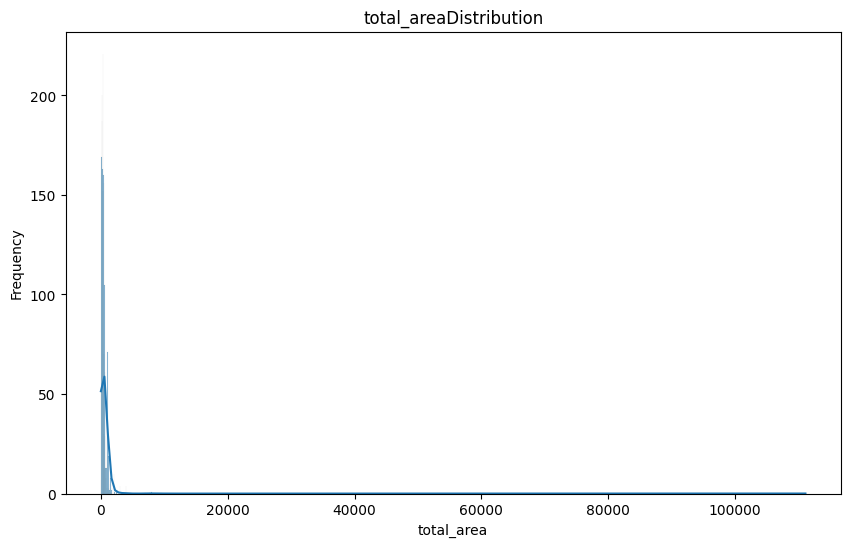

In [200]:
for col in ['total_area']:
    plot_distribution(df_clean[col],col + 'Distribution',col)

In [201]:
df_clean['total_area'].fillna(df_clean['total_area'].median(), inplace=True)

C:\Users\MSI\AppData\Local\Temp\ipykernel_5824\2492172101.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['total_area'].fillna(df_clean['total_area'].median(), inplace=True)


In [202]:
print(df_clean.shape)
df_clean=df_clean.dropna(subset=['payment_period'])
print(df_clean.shape)

(2454, 17)
(2406, 17)


In [203]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2406 entries, 0 to 48
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             2406 non-null   float64
 1   address           2406 non-null   object 
 2   total_area        2406 non-null   float64
 3   rooms             2406 non-null   float64
 4   terrace           2406 non-null   float64
 5   furnished         2406 non-null   float64
 6   air_conditioning  2406 non-null   float64
 7   heating           2406 non-null   float64
 8   security          2406 non-null   float64
 9   latitude          2393 non-null   float64
 10  longitude         2393 non-null   float64
 11  bedrooms          2406 non-null   float64
 12  garage            2406 non-null   float64
 13  garden            2406 non-null   float64
 14  pool              2406 non-null   float64
 15  payment_period    2406 non-null   object 
 16  bathrooms_number  2406 non-null   float64
dtypes:

### c- Handling outliers

For removing outliers we have to consider 2 things , the place and the payment period 

In [204]:
print(df_clean.shape)
print(df_clean['price'].min())
print(df_clean['price'].max())

(2406, 17)
70.0
11000000.0


In [205]:
df_clean=df_clean[df_clean['price']<9999]
print(df_clean.shape)

(2176, 17)


In [206]:
municipality_df=pd.read_csv('municipalities.csv')
municipality_df.head()

,governorate,municipality
0,Tunis,Tunis
1,Tunis,Le Bardo
2,Tunis,Le Kram
3,Tunis,La Goulette
4,Tunis,Carthage


In [207]:
print(municipality_df['governorate'].nunique())
print(municipality_df['governorate'].unique())

24
['Tunis' 'Ariana' 'Ben Arous' 'Manouba' 'Nabeul' 'Zaghouan' 'Bizerte'
 'Béja' 'Jendouba' 'Kef' 'Siliana' 'Sousse' 'Monastir' 'Mahdia' 'Sfax'
 'Kairouan' 'Kasserine' 'Sidi Bouzid' 'Gabès' 'Mednine' 'Tataouine'
 'Gafsa' 'Tozeur' 'Kebili']


In [208]:
print(municipality_df['municipality'].nunique())
print(municipality_df['municipality'].unique())

270
['Tunis' 'Le Bardo' 'Le Kram' 'La Goulette' 'Carthage' 'Sidi Bou Said'
 'La Marsa' 'Sidi Hassine' 'Ariana' 'La Soukra' 'Raoued'
 'Kalâat el-Andalous' 'Sidi Thabet' 'Ettadhamen-Mnihla' 'Ben Arous'
 'El Mourouj' 'Hammam Lif' 'Hammam Chott' 'Bou Mhel el-Bassatine'
 'Ezzahra' 'Radès' 'Mégrine' 'Mohamedia-Fouchana' 'Mornag' 'Khalidia'
 'Manouba' 'Den Den' 'Douar Hicher' 'Oued Ellil' 'Mornaguia'
 'Borj El Amri' 'Djedeida' 'Tebourba' 'El Battan' 'Nabeul' 'Dar Chaabane'
 'Béni Khiar' 'El Maâmoura' 'Somâa' 'Korba' 'Tazerka' 'Menzel Temime'
 'Menzel Horr' 'El Mida' 'Kelibia' 'Azmour' 'Hammam Ghezèze' 'Dar Allouch'
 'El Haouaria' 'Takelsa' 'Soliman' 'Korbous' 'Menzel Bouzelfa'
 'Béni Khalled' 'Zaouiet Djedidi' 'Grombalia' 'Bou Argoub' 'Hammamet'
 'Zaghouan' 'Zriba' 'Bir Mcherga' 'Djebel Oust' 'El Fahs' 'Nadhour'
 'Bizerte' 'Sejnane' 'Mateur' 'Menzel Bourguiba' 'Tinja' 'Ghar al Milh'
 'Aousja' 'Menzel Jemil' 'Menzel Abderrahmane' 'El Alia' 'Ras Jebel'
 'Metline' 'Raf Raf' 'Béja' 'El Maâgoula' 

In [209]:
df_clean["municipality"]=None
df_clean["governorate"]=None

In [210]:
# rename the misspelled columns with a minimum match threshold of 70%
def get_municipality_if_good_match(address):
    match_result = process.extractOne(address, municipality_df["municipality"],
                                             scorer=fuzz.partial_ratio)
    # Only return the municipality name if the match score is above 70%
    if match_result[1] >= 70:
        return match_result[0]
    else:
        return None 
df_clean["municipality"] = df_clean["address"].apply(get_municipality_if_good_match)

In [211]:
df_missing_municipality=df_clean[df_clean['municipality'].isna()]
df_full_municipality=df_clean[df_clean['municipality'].notna()]

In [212]:
# Function to get municipality from latitude and longitude
def get_municipality_from_coords(lat, lon):
    try:
        geolocator = Nominatim(user_agent="apartment_buying_model")
        location = geolocator.reverse((lat, lon), exactly_one=True,language="fr")
        address = location.raw['address']
        
        for field in ['municipality','city', 'town', 'village', 'suburb']:
            if field in address:
                return address[field]
        
        return None
    except Exception as e:
        print(f"Error: {e}")
        return None

for idx, row in df_missing_municipality.iterrows():
    municipality = get_municipality_from_coords(row['latitude'], row['longitude'])
    if municipality:
        df_missing_municipality.at[idx, 'municipality'] = municipality
    else:
        df_missing_municipality.at[idx, 'municipality'] = df_missing_municipality.at[idx,'address']
    time.sleep(1)  # Sleep to respect API rate limits

In [213]:
df_clean=pd.concat([df_missing_municipality,df_full_municipality])

In [214]:
municipality_lst=list(municipality_df['municipality'])
governorate_lst=list(municipality_df['governorate'])
print(len(municipality_lst))
print(len(governorate_lst))

270
270


we fill governorate based on the municipality , exemple : Manar => Ariana

In [215]:
# a dictionary mapping municipalities to governorates
municipality_to_governorate = dict(zip(municipality_lst, governorate_lst))
print(municipality_to_governorate)
# update the governorate column using the mapping
df_clean['governorate'] = df_clean['municipality'].map(municipality_to_governorate)

{'Tunis': 'Tunis', 'Le Bardo': 'Tunis', 'Le Kram': 'Tunis', 'La Goulette': 'Tunis', 'Carthage': 'Tunis', 'Sidi Bou Said': 'Tunis', 'La Marsa': 'Tunis', 'Sidi Hassine': 'Tunis', 'Ariana': 'Ariana', 'La Soukra': 'Ariana', 'Raoued': 'Ariana', 'Kalâat el-Andalous': 'Ariana', 'Sidi Thabet': 'Ariana', 'Ettadhamen-Mnihla': 'Ariana', 'Ben Arous': 'Ben Arous', 'El Mourouj': 'Ben Arous', 'Hammam Lif': 'Ben Arous', 'Hammam Chott': 'Ben Arous', 'Bou Mhel el-Bassatine': 'Ben Arous', 'Ezzahra': 'Ben Arous', 'Radès': 'Ben Arous', 'Mégrine': 'Ben Arous', 'Mohamedia-Fouchana': 'Ben Arous', 'Mornag': 'Ben Arous', 'Khalidia': 'Ben Arous', 'Manouba': 'Manouba', 'Den Den': 'Manouba', 'Douar Hicher': 'Manouba', 'Oued Ellil': 'Manouba', 'Mornaguia': 'Manouba', 'Borj El Amri': 'Manouba', 'Djedeida': 'Manouba', 'Tebourba': 'Manouba', 'El Battan': 'Manouba', 'Nabeul': 'Nabeul', 'Dar Chaabane': 'Nabeul', 'Béni Khiar': 'Nabeul', 'El Maâmoura': 'Nabeul', 'Somâa': 'Nabeul', 'Korba': 'Nabeul', 'Tazerka': 'Nabeul', '

In [216]:
missing_governorate=df_clean[df_clean['governorate'].isnull()]
not_missing_governorate=df_clean[df_clean['governorate'].notna()]
print(len(missing_governorate))
print(len(not_missing_governorate))


63
2113


In [217]:
def get_governorate_from_municipality(municipality_name):
    try:
        geolocator = Nominatim(user_agent="apartment_buying_model")
        # Search for the municipality name in Tunisia
        location = geolocator.geocode(f"{municipality_name}, Tunisia", exactly_one=True, language="fr")
        if location:
            address_details = geolocator.reverse((location.latitude, location.longitude), language="fr").raw['address']
            for field in ['state', 'county', 'region', 'province']:
                if field in address_details:
                    return address_details[field]
        return None
    except Exception as e:
        return None
def get_governorate_from_coords(lat, lon):
    try:
        geolocator = Nominatim(user_agent="apartment_buying_model")
        location = geolocator.reverse((lat, lon), exactly_one=True, language="fr")
        address = location.raw['address']
        
        for field in ['state', 'county', 'region', 'province']:
            if field in address:
                return address[field]
        return None
    except Exception as e:
        return None
# Apply the function to rows with missing governorate but known municipality
for idx, row in missing_governorate.iterrows():
    if pd.notna(row['municipality']):
        # First try using municipality name
        governorate = get_governorate_from_municipality(row['municipality'])
        # If that fails and we have coordinates, try using them
        if not governorate:
            governorate = get_governorate_from_coords(row['latitude'], row['longitude'])   
        if governorate:
            missing_governorate.at[idx, 'governorate'] = governorate
            
        time.sleep(1)  # Sleep to respect API rate limits

In [218]:
print(len(missing_governorate[missing_governorate['governorate'].isnull()]))
print(missing_governorate['governorate'].unique())

0
['Gouvernorat Ariana' 'Gouvernorat Sousse' 'Gouvernorat Médenine'
 'Gouvernorat Nabeul']


In [219]:
# rename the misspelled columns with a minimum match threshold of 70%
def get_governorate_if_good_match(address):
    match_result = process.extractOne(address, municipality_df["governorate"],
                                             scorer=fuzz.partial_ratio)
    # Only return the governorate name if the match score is above 70%
    if match_result[1] >= 70:
        return match_result[0]
    else:
        return None 
missing_governorate["governorate"] = missing_governorate["governorate"].apply(get_governorate_if_good_match)

C:\Users\MSI\AppData\Local\Temp\ipykernel_5824\2345721556.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_governorate["governorate"] = missing_governorate["governorate"].apply(get_governorate_if_good_match)


In [220]:
missing_governorate = missing_governorate.dropna(subset=['governorate'])
print(len(missing_governorate[missing_governorate['governorate'].isnull()]))
print(missing_governorate['governorate'].unique())

0
['Ariana' 'Sousse' 'Mednine' 'Nabeul']


In [221]:
print(df_clean.shape)
df_clean=pd.concat([missing_governorate,not_missing_governorate])
df_clean=df_clean.reset_index(drop=True)
print(df_clean.shape)

(2176, 19)
(2176, 19)


In [222]:
df_clean['municipality'].value_counts()

municipality
La Marsa            923
Hammamet            265
Carthage            165
La Soukra           111
Ariana               77
                   ... 
Korba                 1
Barraket Essahel      1
Sidi Ameur            1
Ksar Hellal           1
Mahdia                1
Name: count, Length: 78, dtype: int64

In [223]:
def clean_outliers(df):
    """
    This function is responsible for removing price outliers based on the prices arround property area
    prices are different from place to place
    -Initally we iniate outliers_mask a pandas series with false values , later we change outliers index
    to have a True value
    -In the end we filter our original dataset with non outliers
    """
    # First, let's check how many rows we have before removing outliers
    print("dataframe size before removing outliers: ", len(df))
    # Create a series object , every value is false at the beginning
    outliers_mask = pd.Series(False, index=df.index)
    # Only process municipalities with enough data points
    min_properties = 5  # Minimum number of properties needed to calculate reliable statistics
    municipality_counts = df['municipality'].value_counts()
    #getting the name of the municipalities that have at least 5 properties to calculate the IQR
    valid_municipalities = municipality_counts[municipality_counts >= min_properties].index

    for municipality in valid_municipalities:
        # Get prices for this municipality
        municipality_prices = df[df['municipality'] == municipality]['price']
        
        # Calculate Q1, Q3 and IQR
        Q1 = municipality_prices.quantile(0.25)
        Q3 = municipality_prices.quantile(0.75)
        IQR = Q3 - Q1
        
        # Define bounds for outliers 
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identify outliers for this municipality
        municipality_outliers = df[
            (df['municipality'] == municipality) & 
            ((df['price'] < lower_bound) | (df['price'] > upper_bound))
        ].index
        
        # Add to our overall outliers mask
        outliers_mask.loc[municipality_outliers] = True
        

    # For municipalities with too few properties, we can use global statistics
    small_municipalities = df['municipality'].isin(
        municipality_counts[municipality_counts < min_properties].index
    )

    if small_municipalities.sum() > 0:
        # Calculate global IQR
        all_prices = df['price']
        global_Q1 = all_prices.quantile(0.25)
        global_Q3 = all_prices.quantile(0.75)
        global_IQR = global_Q3 - global_Q1
        
        global_lower = global_Q1 - 1.5 * global_IQR
        global_upper = global_Q3 + 1.5 * global_IQR
        
        # Identify outliers in small municipalities
        small_muni_outliers = df[
            small_municipalities & 
            ((df['price'] < global_lower) | (df['price'] > global_upper))
        ].index
        
        # Add to our overall outliers mask
        outliers_mask.loc[small_muni_outliers] = True

    # Remove the outliers
    df_clean_no_outliers = df[~outliers_mask].copy() #outliers_mask is a boolean pandas series
    print(f"Dataframe size after removing outliers: ",len(df_clean_no_outliers))
    # Replace the original dataframe with the cleaned one
    return df_clean_no_outliers

In [224]:
df_day=df_clean[df_clean['payment_period']=='Jour']
df_month=df_clean[df_clean['payment_period']=='Mois']
df_week=df_clean[df_clean['payment_period']=='Semaine']
print("Daily renting:")
print(df_day.shape)
df_day=clean_outliers(df_day)
print(df_day.shape)
print("Monthly renting")
print(df_month.shape)
df_month=clean_outliers(df_month)
print(df_month.shape)
print("Weekly renting")
print(df_week.shape)
df_week=clean_outliers(df_week)
print(df_week.shape)

Daily renting:
(117, 19)
dataframe size before removing outliers:  117
Dataframe size after removing outliers:  103
(103, 19)
Monthly renting
(1958, 19)
dataframe size before removing outliers:  1958
Dataframe size after removing outliers:  1937
(1937, 19)
Weekly renting
(101, 19)
dataframe size before removing outliers:  101
Dataframe size after removing outliers:  101
(101, 19)


In [225]:
df_clean=pd.concat([df_day,df_month,df_week])

In [226]:
# Box plot 
def boxplot(df_func,col):
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df_func[col])
    plt.title(col+' Box Plot')
    plt.xlabel('Number of '+col)
    plt.show()

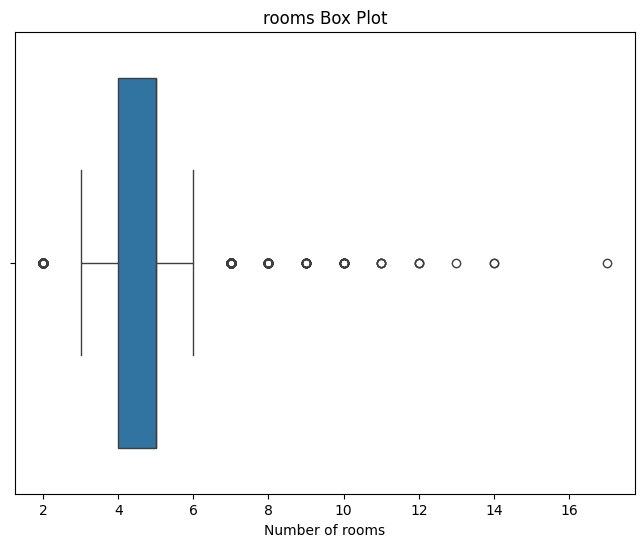

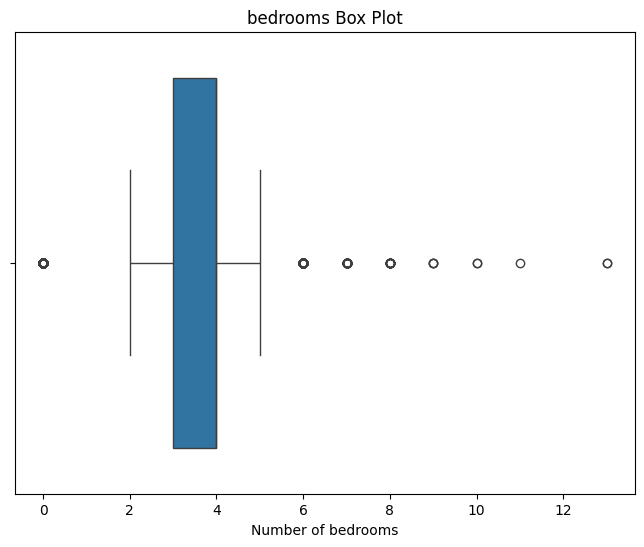

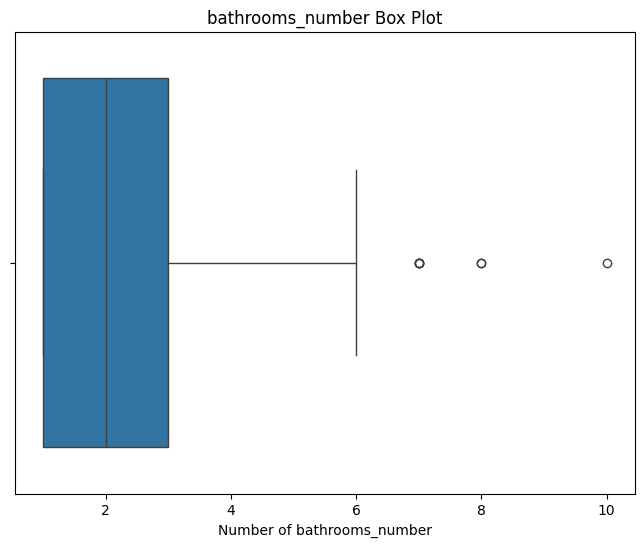

In [227]:
boxplot(df_clean,'rooms') 
boxplot(df_clean,'bedrooms')
boxplot(df_clean,'bathrooms_number')

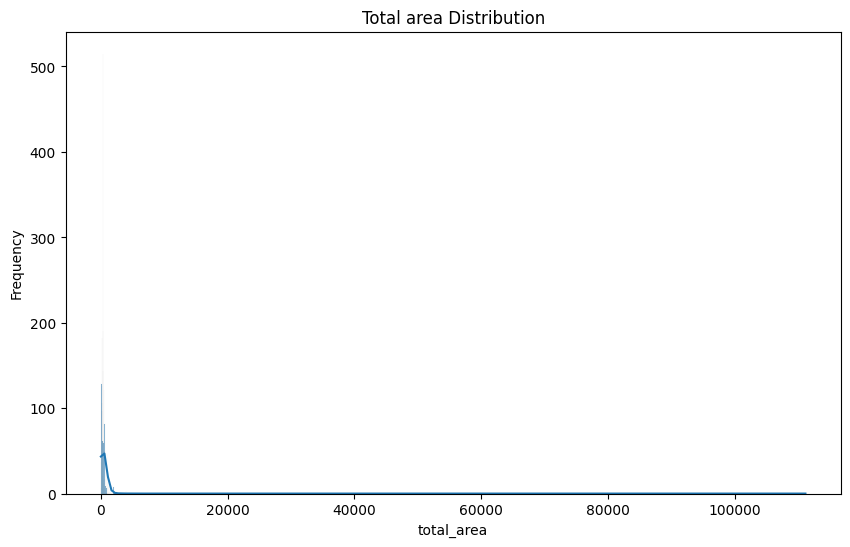

In [228]:
plot_distribution(df_clean['total_area'],'Total area Distribution','total_area')

In [229]:

def remove_outliers_iqr(df, column, k=1.5):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]


In [230]:
print(df_clean.shape)
df_clean = remove_outliers_iqr(df_clean, "total_area")
print(df_clean.shape)


(2141, 19)
(1984, 19)


In [231]:
def remove_outliers_zscore(df, column, threshold=3):
    # Calculate the Z-score for each data point
    mean = df[column].mean()
    std = df[column].std()
    z_scores = (df[column] - mean) / std
    # Filter out the outliers
    return df[np.abs(z_scores) < threshold]

In [232]:

print(df_clean.shape)
for col in ['rooms','bathrooms_number','bedrooms']:
    df_clean=remove_outliers_zscore(df_clean,col)
    print(df_clean.shape)


(1984, 19)
(1963, 19)
(1954, 19)
(1944, 19)


In [233]:
df_clean['payment_period'].value_counts()

payment_period
Mois       1769
Jour         88
Semaine      87
Name: count, dtype: int64

as we can see there is a clear unbalance number of rows between payment period , that will effect
our model badly so we need to balance the distribution .
But we have to be carful not to remove some places in the process , our goal is to balance payment period distrubtion and keep all the municipality

In [234]:
df_clean['municipality'].nunique()

73

In [235]:
# count of the minority class (Jour or class both have basiclly the same)
jour_count = df_clean[df_clean['payment_period'] == 'Jour'].shape[0]
# Get unique municipalities
all_municipalities = df_clean['municipality'].unique()
# Initialize an empty DataFrame to store our balanced sample
balanced_df = pd.DataFrame()
# First we include all Jour records
jour_data = df_clean[df_clean['payment_period'] == 'Jour']
balanced_df = pd.concat([balanced_df, jour_data])
# Include all Semaine records
semaine_data = df_clean[df_clean['payment_period'] == 'Semaine']
balanced_df = pd.concat([balanced_df, semaine_data])
# For Mois category, we are going to use to include the rest of municiplties
mois_data = df_clean[df_clean['payment_period'] == 'Mois']
#  how many samples we need from 'Mois'
mois_sample_size = jour_count

# Ensure each municipality is represented in the 'Mois' sample
mois_sample = pd.DataFrame()
# First, ensure at least one record from each municipality (if available)
for municipality in all_municipalities:
    municipality_mois = mois_data[mois_data['municipality'] == municipality]
    if not municipality_mois.empty:
        # Take at least one sample from each municipality
        mois_sample = pd.concat([mois_sample, municipality_mois.sample(min(1, len(municipality_mois)), random_state=42)])

# If we haven't reached our target sample size, add more records randomly
remaining_sample_size = mois_sample_size - len(mois_sample)
if remaining_sample_size > 0:
    # Exclude already sampled records
    remaining_mois = mois_data[~mois_data.index.isin(mois_sample.index)]
    if not remaining_mois.empty:
        additional_samples = remaining_mois.sample(remaining_sample_size, random_state=42)
        mois_sample = pd.concat([mois_sample, additional_samples])

# Combine all data
balanced_df = pd.concat([balanced_df, mois_sample])
# Shuffle the data
df_clean = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
# Verify that all municipalities are still represented
print("Number of unique municipalities after balancing: ",df_clean['municipality'].nunique())
print("Original number of unique municipalities: ",len(all_municipalities))

Number of unique municipalities after balancing:  73
Original number of unique municipalities:  73


In [236]:
print(df_clean.shape)
print(df_clean["municipality"].nunique())
df_clean['payment_period'].value_counts()

(263, 19)
73


payment_period
Mois       88
Jour       88
Semaine    87
Name: count, dtype: int64

## 3-Data visualization

<Axes: xlabel='price', ylabel='total_area'>

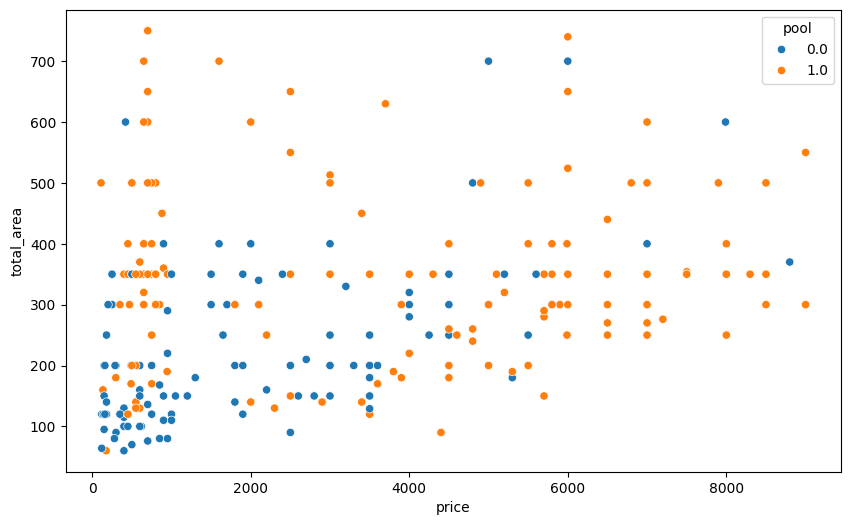

In [237]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_clean['price'], y=df_clean['total_area'],hue=df_clean['pool'])

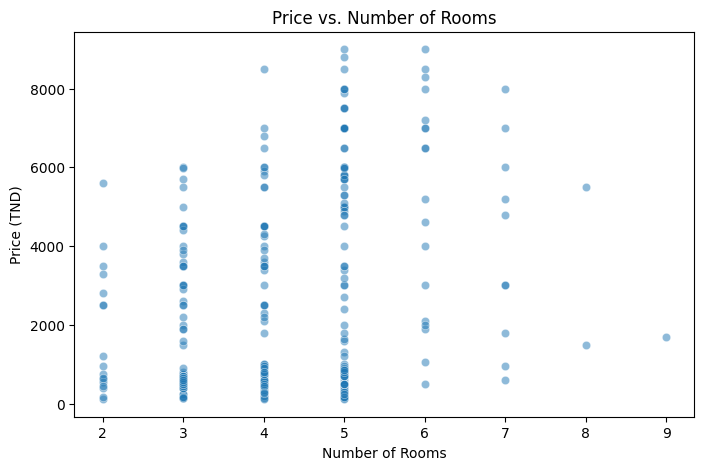

In [238]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='rooms', y='price', data=df_clean, alpha=0.5)
plt.title('Price vs. Number of Rooms')
plt.xlabel('Number of Rooms')
plt.ylabel('Price (TND)')
plt.show()

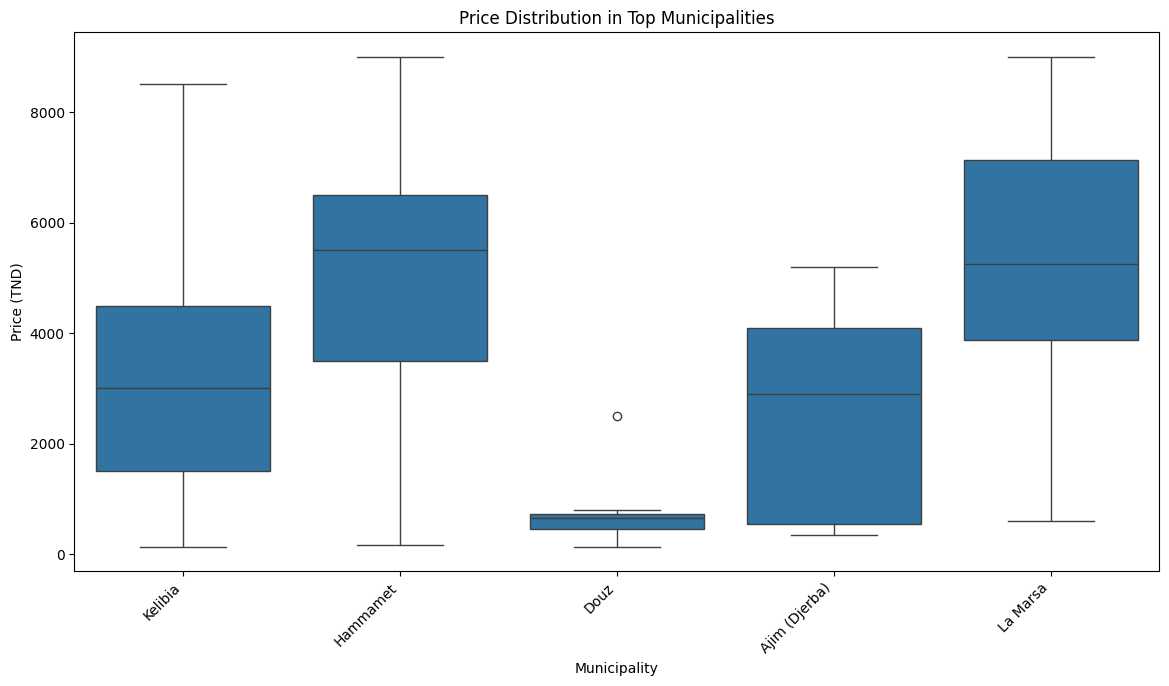

In [239]:
top_municipalities = df_clean.groupby('municipality')['price'].count().sort_values(ascending=False)
top_municipalities = top_municipalities[top_municipalities > 5].index[:5]
plt.figure(figsize=(14, 7))
sns.boxplot(x='municipality', y='price', 
            data=df_clean[df_clean['municipality'].isin(top_municipalities)])
plt.title('Price Distribution in Top Municipalities')
plt.xlabel('Municipality')
plt.ylabel('Price (TND)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [240]:
def count_figure(col):
    plt.figure(figsize=(7, 5))
    sns.countplot(data=df_clean, x=col, palette='deep')
    plt.title('Distribution of Apartments by '+col)
    plt.ylabel('Number of Apartments')
    plt.tight_layout()
    plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_5824\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


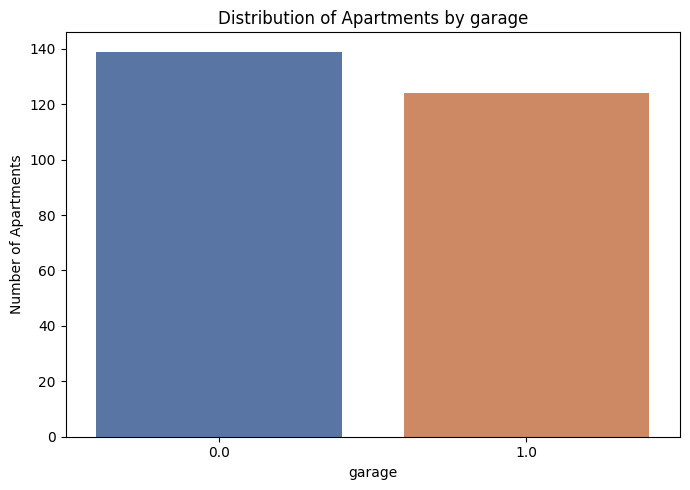

C:\Users\MSI\AppData\Local\Temp\ipykernel_5824\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


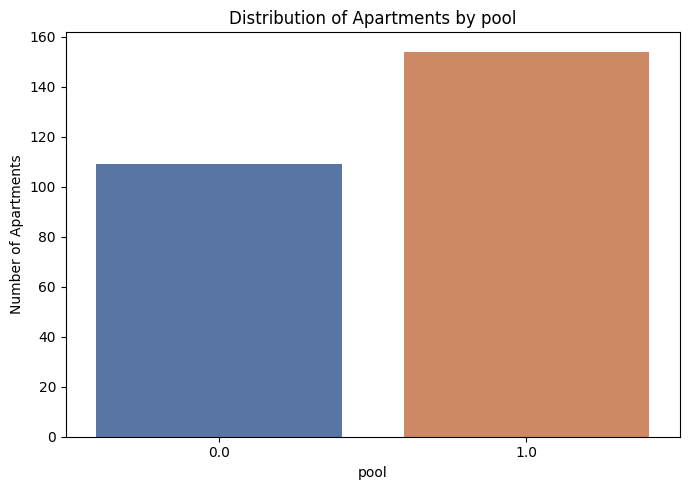

C:\Users\MSI\AppData\Local\Temp\ipykernel_5824\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


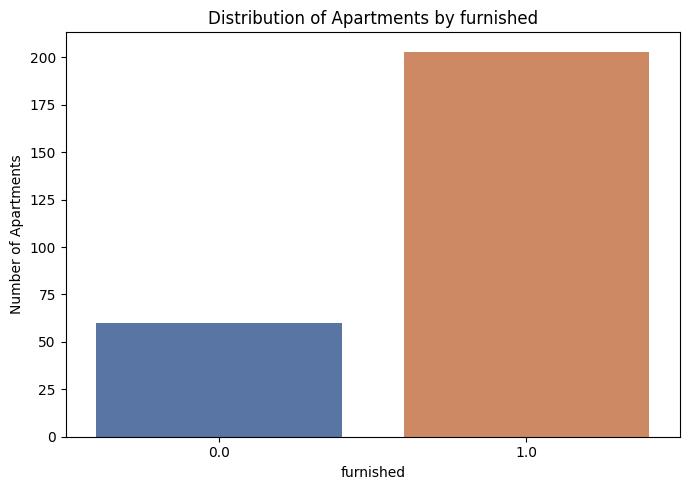

C:\Users\MSI\AppData\Local\Temp\ipykernel_5824\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


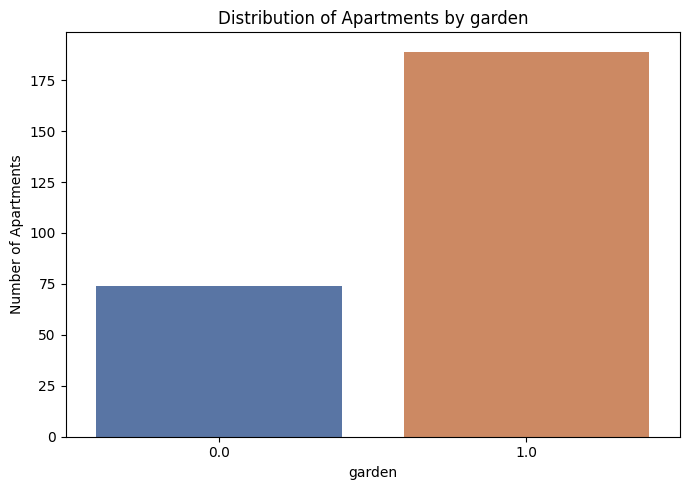

C:\Users\MSI\AppData\Local\Temp\ipykernel_5824\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


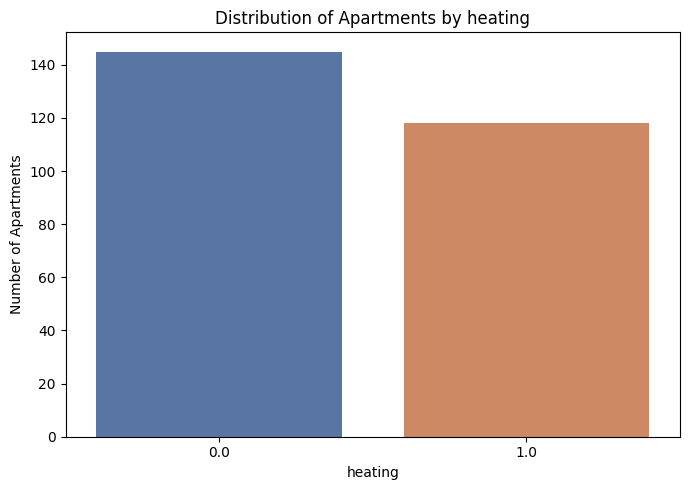

C:\Users\MSI\AppData\Local\Temp\ipykernel_5824\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


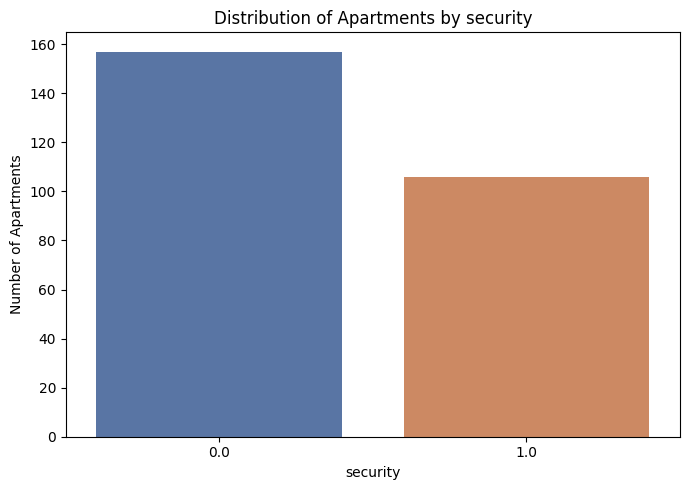

C:\Users\MSI\AppData\Local\Temp\ipykernel_5824\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


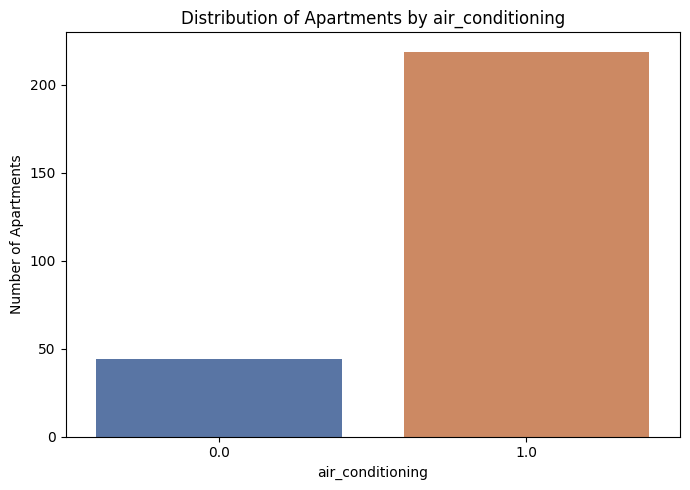

C:\Users\MSI\AppData\Local\Temp\ipykernel_5824\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


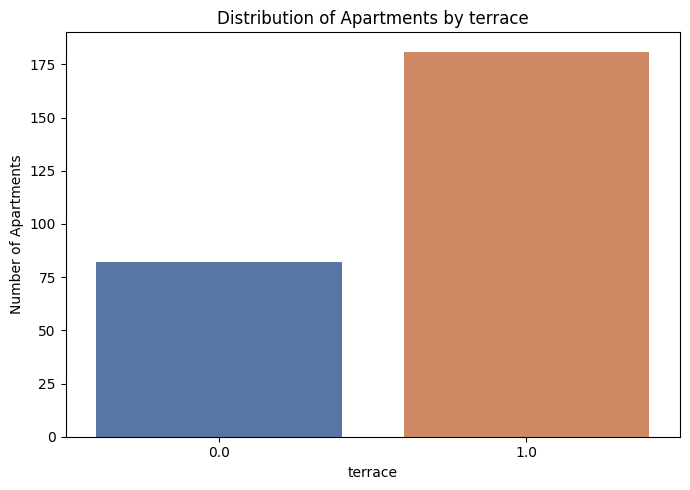

In [241]:
for col in ['garage','pool','furnished','garden','heating','security','air_conditioning','terrace']:
    count_figure(col)

## 4-Feature engineering and selection

In [242]:
# Round latitude and longitude to 4 decimal places
df_clean['latitude'] = df_clean['latitude'].round(4)
df_clean['longitude'] = df_clean['longitude'].round(4)
# Check the rounded values
print(df_clean[['latitude', 'longitude']].head())

   latitude  longitude
0   36.8493    11.0918
1   36.4011    10.6146
2   36.8833    10.2500
3   36.7609    10.2736
4   33.7597    11.0125


now we are going to add some extra information about the address so we can better describe it
cause latitude and longitude are not enough

In [243]:
df_clean.shape

(263, 19)

In [244]:
df_clean['governorate'].nunique()

19

In [245]:
municipality_governorate_description=pd.read_csv('municipality_governorate_description.csv')
print(municipality_governorate_description['governorate'].nunique())
municipality_governorate_description=municipality_governorate_description.drop(columns=
['municipality_avg_price','governorate_avg_price','governorate'])
municipality_governorate_description.head()

24


,municipality,municipality_quality,municipality_quality_confidence,governorate_quality,governorate_quality_confidence
0,Ajim (Djerba),mid_price_housing_area,high,mid_price_housing_area,high
1,Akouda,premium_housing_area,high,premium_housing_area,high
2,Ariana,premium_housing_area,high,premium_housing_area,high
3,Aïn Draham,affordable_housing_area,low,affordable_housing_area,high
4,Bembla-Mnara,affordable_housing_area,low,mid_price_housing_area,high


In [246]:
print(df_clean.shape)
df_clean=df_clean.merge(municipality_governorate_description,on='municipality',how='left')
print(df_clean.shape)
df_clean.head()

(263, 19)
(263, 23)


,price,address,total_area,rooms,terrace,furnished,air_conditioning,heating,security,latitude,...,garden,pool,payment_period,bathrooms_number,municipality,governorate,municipality_quality,municipality_quality_confidence,governorate_quality,governorate_quality_confidence
0,8500.0,Kélibia,500.0,4.0,1.0,1.0,1.0,0.0,1.0,36.8493,...,1.0,1.0,Semaine,2.0,Kelibia,Nabeul,affordable_housing_area,high,mid_price_housing_area,high
1,5800.0,Yasmine Hammamet à Hammamet,400.0,5.0,1.0,1.0,1.0,1.0,1.0,36.4011,...,1.0,1.0,Semaine,2.0,Hammamet,Nabeul,premium_housing_area,high,mid_price_housing_area,high
2,4500.0,Aéroport Tunis Carthage à La Soukra,400.0,3.0,0.0,0.0,0.0,0.0,0.0,36.8833,...,1.0,1.0,Mois,1.0,Tunis,Tunis,premium_housing_area,high,premium_housing_area,high
3,620.0,Rades Meliane à Rades,100.0,2.0,0.0,0.0,0.0,0.0,0.0,36.7609,...,1.0,0.0,Mois,1.0,Metline,Bizerte,mid_price_housing_area,high,affordable_housing_area,high
4,550.0,Aghir,350.0,3.0,0.0,1.0,1.0,0.0,0.0,33.7597,...,0.0,1.0,Jour,3.0,Kalâa Seghira,Sousse,mid_price_housing_area,high,premium_housing_area,high


In [247]:
df_clean=df_clean.drop(columns=['address','municipality','governorate'])
df_clean.head()

,price,total_area,rooms,terrace,furnished,air_conditioning,heating,security,latitude,longitude,bedrooms,garage,garden,pool,payment_period,bathrooms_number,municipality_quality,municipality_quality_confidence,governorate_quality,governorate_quality_confidence
0,8500.0,500.0,4.0,1.0,1.0,1.0,0.0,1.0,36.8493,11.0918,4.0,0.0,1.0,1.0,Semaine,2.0,affordable_housing_area,high,mid_price_housing_area,high
1,5800.0,400.0,5.0,1.0,1.0,1.0,1.0,1.0,36.4011,10.6146,4.0,1.0,1.0,1.0,Semaine,2.0,premium_housing_area,high,mid_price_housing_area,high
2,4500.0,400.0,3.0,0.0,0.0,0.0,0.0,0.0,36.8833,10.2500,3.0,1.0,1.0,1.0,Mois,1.0,premium_housing_area,high,premium_housing_area,high
3,620.0,100.0,2.0,0.0,0.0,0.0,0.0,0.0,36.7609,10.2736,2.0,0.0,1.0,0.0,Mois,1.0,mid_price_housing_area,high,affordable_housing_area,high
4,550.0,350.0,3.0,0.0,1.0,1.0,0.0,0.0,33.7597,11.0125,3.0,1.0,0.0,1.0,Jour,3.0,mid_price_housing_area,high,premium_housing_area,high


In [248]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   price                            263 non-null    float64
 1   total_area                       263 non-null    float64
 2   rooms                            263 non-null    float64
 3   terrace                          263 non-null    float64
 4   furnished                        263 non-null    float64
 5   air_conditioning                 263 non-null    float64
 6   heating                          263 non-null    float64
 7   security                         263 non-null    float64
 8   latitude                         260 non-null    float64
 9   longitude                        260 non-null    float64
 10  bedrooms                         263 non-null    float64
 11  garage                           263 non-null    float64
 12  garden                

In [249]:
df_clean=df_clean.dropna()

In [250]:
categorical_cols = ['payment_period','municipality_quality','municipality_quality_confidence',
                    'governorate_quality','governorate_quality_confidence'] 
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
df_encoded.head()

,price,total_area,rooms,terrace,furnished,air_conditioning,heating,security,latitude,longitude,...,garden,pool,bathrooms_number,payment_period_Mois,payment_period_Semaine,municipality_quality_mid_price_housing_area,municipality_quality_premium_housing_area,municipality_quality_confidence_low,governorate_quality_mid_price_housing_area,governorate_quality_premium_housing_area
0,8500.0,500.0,4.0,1.0,1.0,1.0,0.0,1.0,36.8493,11.0918,...,1.0,1.0,2.0,False,True,False,False,False,True,False
1,5800.0,400.0,5.0,1.0,1.0,1.0,1.0,1.0,36.4011,10.6146,...,1.0,1.0,2.0,False,True,False,True,False,True,False
2,4500.0,400.0,3.0,0.0,0.0,0.0,0.0,0.0,36.8833,10.2500,...,1.0,1.0,1.0,True,False,False,True,False,False,True
3,620.0,100.0,2.0,0.0,0.0,0.0,0.0,0.0,36.7609,10.2736,...,1.0,0.0,1.0,True,False,True,False,False,False,False
4,550.0,350.0,3.0,0.0,1.0,1.0,0.0,0.0,33.7597,11.0125,...,0.0,1.0,3.0,False,False,True,False,False,False,True


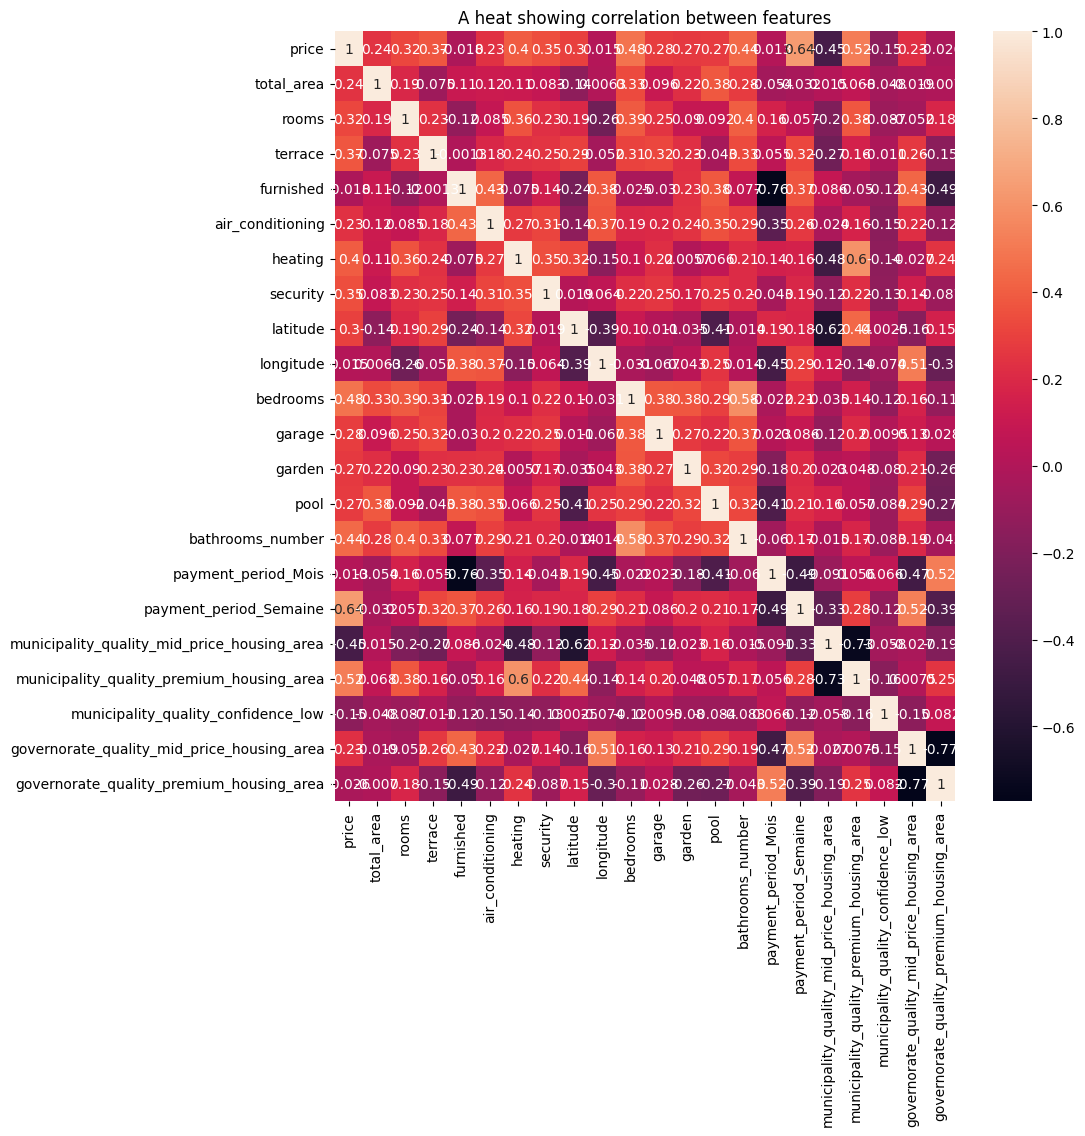

In [251]:
plt.figure(figsize=(10, 10))
sns.heatmap(df_encoded.corr(), annot=True)
plt.title("A heat showing correlation between features")
plt.show()


In [252]:
#df_encoded.to_csv('house_location_clean_data.csv',index=False)

In [260]:

df=pd.read_csv('synthatic_house_renting.csv')
df.head()


,price,total_area,rooms,terrace,furnished,air_conditioning,heating,security,latitude,longitude,...,garden,pool,bathrooms_number,payment_period_Mois,payment_period_Semaine,municipality_quality_mid_price_housing_area,municipality_quality_premium_housing_area,municipality_quality_confidence_low,governorate_quality_mid_price_housing_area,governorate_quality_premium_housing_area
0,1800.0,350,4,1,1,1,1,0,36.4011,10.6146,...,1,0,1,True,False,False,True,False,False,True
1,150.0,150,3,1,1,1,0,0,36.9479,11.0938,...,0,0,2,False,False,False,False,False,False,True
2,550.0,350,3,0,1,1,0,0,33.8076,10.8451,...,0,1,2,False,False,True,False,True,True,False
3,4500.0,350,4,1,0,1,1,0,36.9177,10.2889,...,1,0,3,True,False,False,True,False,False,True
4,500.0,350,3,0,1,1,0,0,33.7597,11.0125,...,1,1,2,False,False,False,False,False,True,False


In [261]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 22 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   price                                        2460 non-null   float64
 1   total_area                                   2460 non-null   int64  
 2   rooms                                        2460 non-null   int64  
 3   terrace                                      2460 non-null   int64  
 4   furnished                                    2460 non-null   int64  
 5   air_conditioning                             2460 non-null   int64  
 6   heating                                      2460 non-null   int64  
 7   security                                     2460 non-null   int64  
 8   latitude                                     2460 non-null   float64
 9   longitude                                    2460 non-null   float64
 10  

## Modeling

In [255]:
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor

In [262]:
X=df.drop(columns=['price'],axis=1)
print(X.shape)
y=df['price']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

(2460, 21)


In [133]:
X.columns

Index(['total_area', 'rooms', 'terrace', 'furnished', 'air_conditioning',
       'heating', 'security', 'latitude', 'longitude', 'bedrooms', 'garage',
       'garden', 'pool', 'bathrooms_number', 'payment_period_Mois',
       'payment_period_Semaine', 'municipality_quality_mid_price_housing_area',
       'municipality_quality_premium_housing_area',
       'municipality_quality_confidence_low',
       'governorate_quality_mid_price_housing_area',
       'governorate_quality_premium_housing_area'],
      dtype='object')

In [124]:
# Define the function to evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    
    
    print("Model: ",model_name)
    print(f"Training R²: {train_r2:.3f}, Test R²: {test_r2:.3f}")
    print(f"Training MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    print(f"R² Difference (Overfitting): {train_r2 - test_r2:.3f}")

In [125]:
def cross_val_evaluate(model):
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f"\nCross-validation R² scores: {cv_scores}")
    print(f"Mean CV R² score: {np.mean(cv_scores):.4f}")
    print(f"Standard deviation of CV R² scores: {np.std(cv_scores):.4f}")

    # Get feature importances
    feature_importances = model.feature_importances_
    features = X_train.columns
    importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
    importance_df = importance_df.sort_values('Importance', ascending=False).head(15)
    # Plot
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel('Importance')
    plt.title('Top 15 Feature Importances')
    plt.gca().invert_yaxis()  # Display the most important feature at the top
    plt.tight_layout()
    plt.show()

### Linear Regression

In [263]:
lr=LinearRegression()
# Add StandardScaler for feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test,"Linear Regression")

Model:  Linear Regression
Training R²: 0.794, Test R²: 0.777
Training MAE: 838.72, Test MAE: 874.39
R² Difference (Overfitting): 0.017


### Decision Tree Regressor

Starting hyperparameter search for Decision Tree...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Hyperparameter search completed!
Best parameters: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.3, 'max_depth': None}
Model:  Decision Tree
Training R²: 0.992, Test R²: 0.992
Training MAE: 45.76, Test MAE: 57.58
R² Difference (Overfitting): -0.000

Cross-validation R² scores: [0.98237323 0.97155674 0.97720705 0.98243657 0.96706327]
Mean CV R² score: 0.9761
Standard deviation of CV R² scores: 0.0061


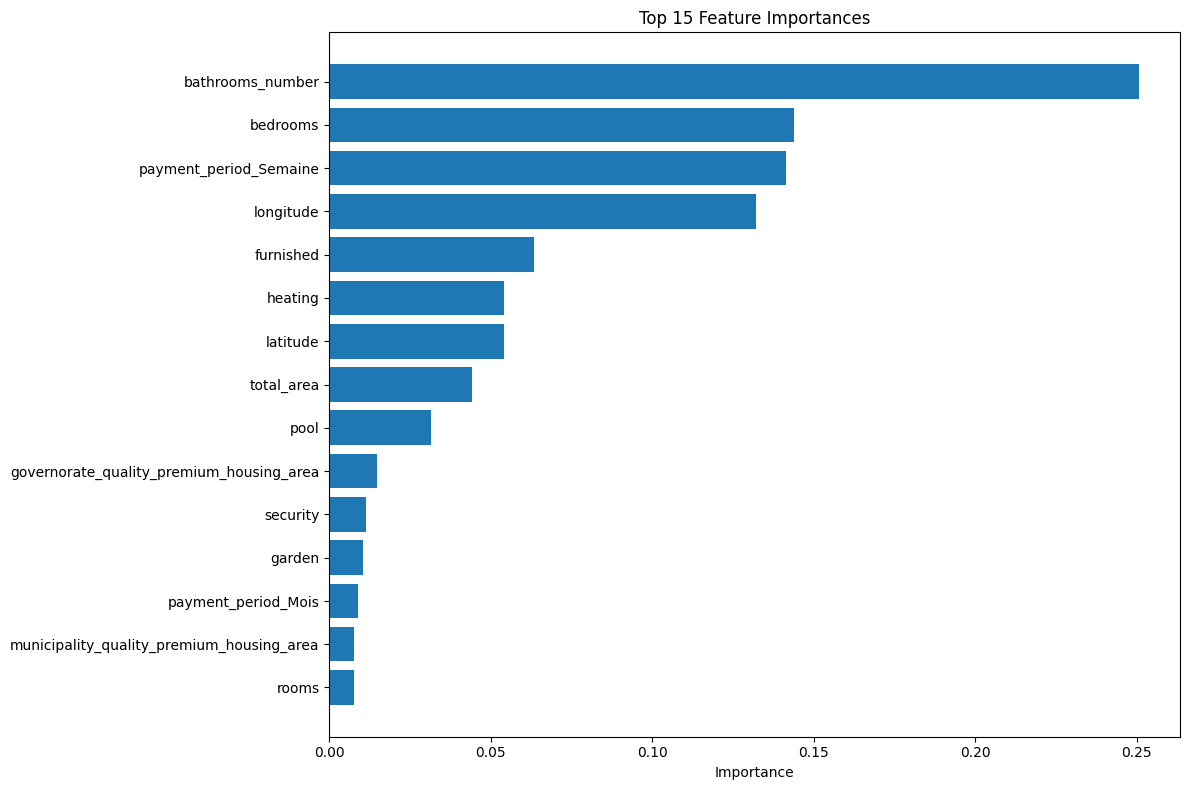

In [264]:
# Define the parameter distribution for Decision Tree
param_dist = {
    'max_depth': [5, 6, 7, 8, 10, 15, None],  # Maximum depth of the tree
    'min_samples_split': [5, 10, 15, 20, 25],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [2, 4, 6, 8, 10],  # Minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7]  # Number of features to consider when looking for the best split
}
# Create a base Decision Tree model
dt = DecisionTreeRegressor(random_state=42)
# Create a cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)
# Set up RandomizedSearchCV with a scoring metric that penalizes complexity
dt_random = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=100,  # Number of parameter settings sampled
    cv=cv,       # 5-fold cross-validation with shuffling
    verbose=2,   # Controls the verbosity of the output
    random_state=42,
    n_jobs=-1,   # Use all available cores
    scoring='neg_mean_absolute_error'  # Focus on error minimization
)
# Fit RandomizedSearchCV
print("Starting hyperparameter search for Decision Tree...")
dt_random.fit(X_train, y_train)
print("Hyperparameter search completed!")
# Get the best parameters and score
print(f"Best parameters: {dt_random.best_params_}")
# Create a model with the best parameters
best_dt = DecisionTreeRegressor(**dt_random.best_params_, random_state=42)
evaluate_model(best_dt, X_train, X_test, y_train, y_test, "Decision Tree")
cross_val_evaluate(best_dt)

In [ ]:
"""
import pickle
with open('house_renting_full.pkl','wb') as file:
    pickle.dump(best_dt,file)
    """